# 격자에서 호(戶)까지 — 폭염·한파 대응의 해상도 문제

**2026 주소정보 활용 대국민 공모전 / 정책 아이디어 분야 · 첨부 분석자료**

---

## 이 분석이 답하려는 질문

폭염·한파 특보는 **시·군·구 단위**로 발령된다. 취약계층 통계는 **행정구역 단위·수년 주기**로 집계된다.
그런데 사람이 쓰러지는 곳은 시·군·구가 아니라 **특정한 집, 특정한 밭**이다.

> **행정구역이라는 단위는 위험을 설명하기에 충분한가?**

충분하지 않다면, 더 촘촘한 공간 기준자가 필요하다. 이 제안은 그 기준자로 **주소정보**를 쓰자고 말한다.
아래 분석은 그 전제 — *행정구역 단위로는 부족하다* — 를 실제 관측자료로 검증한다.

## 데이터

기상청 **기상자료개방포털**의 기후통계분석 자료를 전국 종관기상관측(ASOS) 지점 단위로 수집했다.
API 키·로그인 없이 공개 CSV 다운로드 엔드포인트를 사용한다.

| 지표 | 정의 |
|---|---|
| 폭염일수 | 일 최고기온 33℃ 이상인 날 |
| 열대야일수 | 밤 최저기온 25℃ 이상인 날 |
| 한파일수 | 한파 기준에 해당한 날 |

수집 기간은 2016–2026년이며, 연 단위 비교에는 연도가 완결된 **2016–2025년**만 사용한다.

## 1. 준비

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import pandas as pd

for cand in ["AppleGothic", "Malgun Gothic", "NanumGothic"]:
    if any(f.name == cand for f in fm.fontManager.ttflist):
        plt.rcParams["font.family"] = cand
        break
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_rows", 120)

## 2. 데이터 수집

`collect_kma.py`가 지점별로 세 지표의 CSV를 내려받아 `kma_climate_days.csv`로 저장한다.
아래 셀은 이미 수집된 파일을 읽는다. (재수집은 `python collect_kma.py`)

In [2]:
df = pd.read_csv("kma_climate_days.csv")
print(df.shape)
print(df["지표"].value_counts())
df.head()

(2897, 6)
지표
한파일수     1044
폭염일수      934
열대야일수     919
Name: count, dtype: int64


,stn_id,지점명,시도,연도,지표,일수
0,105,강릉,강원특별자치도,2016,열대야일수,13.0
1,105,강릉,강원특별자치도,2017,열대야일수,15.0
2,105,강릉,강원특별자치도,2018,열대야일수,25.0
3,105,강릉,강원특별자치도,2019,열대야일수,21.0
4,105,강릉,강원특별자치도,2020,열대야일수,16.0


In [3]:
# 연도가 완결된 구간만 사용 (2026년은 진행 중)
full = df[df["연도"].between(2016, 2025)]

# 지점 × 지표 → 연평균 일수
wide = (
    full.pivot_table(index=["stn_id", "지점명", "시도"], columns="지표",
                     values="일수", aggfunc="mean")
    .reset_index()
    .rename_axis(columns=None)
)
print(f"지점 수: {len(wide)}")
wide.sort_values("폭염일수", ascending=False).head(10).round(1)

지점 수: 98


,stn_id,지점명,시도,열대야일수,폭염일수,한파일수
27,143,대구,대구광역시,20.8,36.7,0.7
90,283,경주시,경상북도,8.7,35.0,0.8
92,285,합천,경상남도,6.9,34.0,2.0
97,296,북부산,부산광역시,27.7,33.3,0.3
78,263,의령군,경상남도,11.9,32.7,2.1
71,255,북창원,경상남도,27.9,31.5,0.0
88,279,구미,경상북도,8.7,31.4,0.7
20,131,청주,충청북도,29.2,29.8,2.2
79,264,함양군,경상남도,2.1,29.1,1.7
85,276,청송군,경상북도,0.4,27.7,13.2


## 3. 분석 ① — 같은 특보구역 안에서도 폭염은 다르게 온다

폭염특보는 시·군·구 단위로 나가고, 광역 단위로 언론에 보도된다.
그렇다면 **같은 시·도 안의 관측지점들은 비슷한 폭염을 겪을까?**

In [4]:
gap = (
    wide.groupby("시도")["폭염일수"]
    .agg(지점수="count", 최소="min", 최대="max", 평균="mean", 표준편차="std")
    .assign(격차=lambda d: d["최대"] - d["최소"])
    .sort_values("격차", ascending=False)
)
gap.round(1)

,지점수,최소,최대,평균,표준편차,격차
시도,,,,,,
경상북도,10,1.0,35.0,19.7,11.2,34.0
강원특별자치도,14,0.2,24.6,14.7,7.6,24.4
경상남도,10,10.0,34.0,25.0,7.4,24.0
전남광주통합특별시,14,4.5,25.9,15.4,6.9,21.4
전북특별자치도,10,7.3,26.8,20.4,6.6,19.5
충청북도,6,12.4,29.8,19.0,6.7,17.4
제주특별자치도,4,4.3,20.8,9.3,7.7,16.5
충청남도,6,11.4,23.5,17.0,4.8,12.1
인천광역시,3,0.0,7.7,4.4,4.0,7.7


In [5]:
multi = gap[gap["지점수"] >= 3]
print(f"관측지점 3개 이상인 시도: {len(multi)}개")
print(f"이들의 시도 내부 폭염일수 격차 평균: {multi['격차'].mean():.1f}일")
print(f"가장 큰 내부 격차: {multi['격차'].max():.1f}일 ({multi['격차'].idxmax()})")

# 전국 지점 간 전체 편차와 비교
print(f"\n전국 지점 간 폭염일수 표준편차: {wide['폭염일수'].std():.1f}일")
print(f"시도 내부 표준편차의 평균     : {multi['표준편차'].mean():.1f}일")
print("→ 시도로 묶어도 내부 편차가 거의 줄지 않는다면, 시도는 위험의 단위가 아니다.")

관측지점 3개 이상인 시도: 10개
이들의 시도 내부 폭염일수 격차 평균: 18.3일
가장 큰 내부 격차: 34.0일 (경상북도)

전국 지점 간 폭염일수 표준편차: 8.6일
시도 내부 표준편차의 평균     : 6.6일
→ 시도로 묶어도 내부 편차가 거의 줄지 않는다면, 시도는 위험의 단위가 아니다.


**해석의 핵심** — 시·도 단위로 묶었을 때 내부 편차가 전국 편차만큼 남는다면,
그 행정구역은 위험을 설명하는 단위로서 정보량이 거의 없다는 뜻이다.
아래 그림은 시·도별로 소속 지점들의 연평균 폭염일수를 늘어놓은 것이다.
점들이 넓게 흩어진 시·도일수록, 하나의 특보로 묶어 대응하기 어렵다.

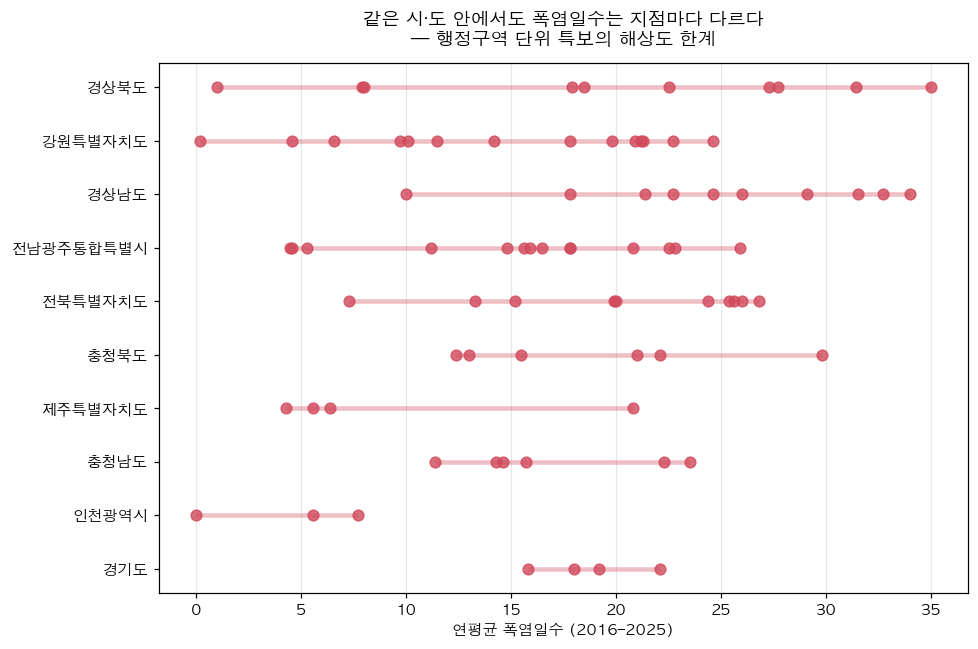

In [6]:
order = multi.sort_values("격차").index.tolist()
fig, ax = plt.subplots(figsize=(9, 6))
for i, sido in enumerate(order):
    vals = wide.loc[wide["시도"] == sido, "폭염일수"].dropna()
    ax.hlines(i, vals.min(), vals.max(), color="#d1495b", alpha=.35, lw=3)
    ax.plot(vals, [i] * len(vals), "o", color="#d1495b", alpha=.8, ms=7)
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.set_xlabel("연평균 폭염일수 (2016–2025)")
ax.set_title("같은 시·도 안에서도 폭염일수는 지점마다 다르다\n— 행정구역 단위 특보의 해상도 한계",
             fontsize=12, pad=12)
ax.grid(axis="x", alpha=.3)
plt.tight_layout()
plt.show()

## 4. 분석 ② — 폭염과 한파를 함께 겪는 지역

폭염 대책과 한파 대책은 보통 별도 사업, 별도 예산, 별도 명부로 운영된다.
그러나 **두 위험을 동시에 겪는 지역**이 있다면, 그곳의 주민은 1년에 두 번 위험해진다.

In [7]:
both = wide.dropna(subset=["폭염일수", "한파일수"])
hot_med, cold_med = both["폭염일수"].median(), both["한파일수"].median()
dual = both[(both["폭염일수"] > hot_med) & (both["한파일수"] > cold_med)]

print(f"분석 대상 지점: {len(both)}개")
print(f"폭염·한파 모두 중앙값 초과: {len(dual)}개 ({len(dual)/len(both)*100:.0f}%)")
print(f"\n폭염일수 중앙값 {hot_med:.1f}일 / 한파일수 중앙값 {cold_med:.1f}일")
dual.sort_values("폭염일수", ascending=False)[
    ["지점명", "시도", "폭염일수", "열대야일수", "한파일수"]].round(1).head(15)

분석 대상 지점: 86개
폭염·한파 모두 중앙값 초과: 23개 (27%)

폭염일수 중앙값 18.7일 / 한파일수 중앙값 1.6일


,지점명,시도,폭염일수,열대야일수,한파일수
92,합천,경상남도,34.0,6.9,2.0
78,의령군,경상남도,32.7,11.9,2.1
20,청주,충청북도,29.8,29.2,2.2
79,함양군,경상남도,29.1,2.1,1.7
85,청송군,경상북도,27.7,0.4,13.2
23,안동,경상북도,27.3,6.6,6.2
21,대전,대전광역시,26.6,22.3,2.5
70,순창군,전북특별자치도,25.4,5.8,3.3
54,정선군,강원특별자치도,24.6,0.5,16.2
65,남원,전북특별자치도,24.4,6.5,2.9


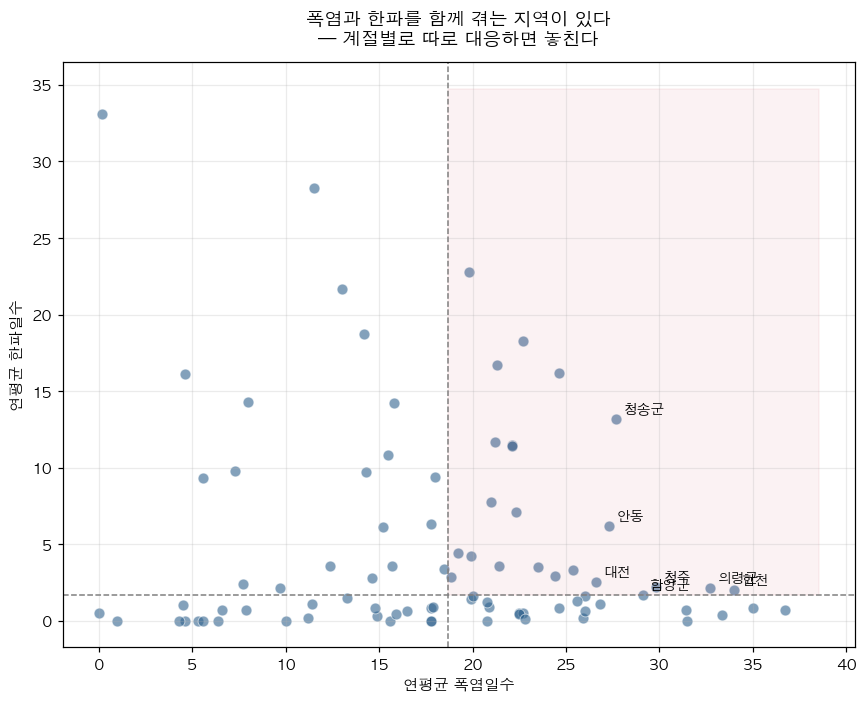

In [8]:
fig, ax = plt.subplots(figsize=(8, 6.5))
ax.scatter(both["폭염일수"], both["한파일수"], s=50, alpha=.6,
           color="#30638e", edgecolor="white", linewidth=.6)
ax.axvline(hot_med, color="gray", ls="--", lw=1)
ax.axhline(cold_med, color="gray", ls="--", lw=1)
ax.fill_between([hot_med, both["폭염일수"].max() * 1.05],
                cold_med, both["한파일수"].max() * 1.05,
                color="#d1495b", alpha=.07)
for _, r in dual.nlargest(7, "폭염일수").iterrows():
    ax.annotate(r["지점명"], (r["폭염일수"], r["한파일수"]),
                fontsize=9, xytext=(5, 4), textcoords="offset points")
ax.set_xlabel("연평균 폭염일수")
ax.set_ylabel("연평균 한파일수")
ax.set_title("폭염과 한파를 함께 겪는 지역이 있다\n— 계절별로 따로 대응하면 놓친다",
             fontsize=12, pad=12)
ax.grid(alpha=.25)
plt.tight_layout()
plt.show()

## 5. 분석 ③ — 열대야: 주거의 문제로 넘어가는 지점

낮의 폭염은 그늘·쉼터로 피할 수 있다. 그러나 **열대야는 집에서 겪는다.**
밤 최저기온이 25℃ 아래로 내려가지 않는 날이 길어질수록,
냉방을 못 하는 주거 형태(반지하·옥탑·쪽방)의 위험은 직접적으로 커진다.

여기서 기상 데이터의 역할은 끝나고, **주소 데이터의 역할이 시작된다.**

In [9]:
top_tn = wide.nlargest(15, "열대야일수")[["지점명", "시도", "열대야일수", "폭염일수"]]
print("=== 연평균 열대야일수 상위 15개 지점 ===")
display(top_tn.round(1))

corr = wide[["폭염일수", "열대야일수"]].corr().iloc[0, 1]
print(f"\n폭염일수 - 열대야일수 상관계수: {corr:.2f}")
print("→ 사실상 무관하다. 낮이 더운 곳과 밤이 안 식는 곳은 서로 다른 곳이다.")

=== 연평균 열대야일수 상위 15개 지점 ===


,지점명,시도,열대야일수,폭염일수
43,제주,제주특별자치도,50.6,20.8
46,서귀포,제주특별자치도,43.9,6.4
44,고산,제주특별자치도,37.6,4.3
45,성산,제주특별자치도,34.0,5.6
35,여수,전남광주통합특별시,33.2,4.6
34,목포,전남광주통합특별시,32.1,11.2
32,부산,부산광역시,31.5,NaN
25,포항,경상북도,30.9,22.5
20,청주,충청북도,29.2,29.8
71,북창원,경상남도,27.9,31.5



폭염일수 - 열대야일수 상관계수: -0.01
→ 사실상 무관하다. 낮이 더운 곳과 밤이 안 식는 곳은 서로 다른 곳이다.


**상관계수가 0에 가깝다**는 것은 예상 밖의 강한 결과다.
낮 최고기온 기준으로 발령되는 **폭염특보는 야간 위험을 거의 예측하지 못한다.**

실제로 서귀포는 연평균 폭염일수가 6.4일에 불과하지만 **열대야는 43.9일**이다.
반대로 내륙 분지는 폭염일수가 높아도 밤에는 식는다.
해안·도서와 내륙이 정반대 패턴을 보이며 서로 상쇄된 결과다.

즉 **"오늘 폭염경보"는 "오늘 밤 당신 집이 위험하다"는 뜻이 아니다.**
야간 위험은 기온이 아니라 **어떤 집에 사는가**로 결정되며, 그것은 주소가 아는 정보다.

In [10]:
# 폭염 대비 열대야가 상대적으로 심한 지점 = '밤에 식지 않는 곳'
w = wide.dropna(subset=["폭염일수", "열대야일수"]).copy()
z = lambda s: (s - s.mean()) / s.std()
w["야간편중"] = z(w["열대야일수"]) - z(w["폭염일수"])

print("=== 낮 더위 대비 밤이 유독 안 식는 지점 (주거 대책 우선 후보) ===")
display(w.nlargest(10, "야간편중")[
    ["지점명", "시도", "폭염일수", "열대야일수", "야간편중"]].round(2))

=== 낮 더위 대비 밤이 유독 안 식는 지점 (주거 대책 우선 후보) ===


,지점명,시도,폭염일수,열대야일수,야간편중
46,서귀포,제주특별자치도,6.4,43.9,4.15
44,고산,제주특별자치도,4.3,37.6,3.83
35,여수,전남광주통합특별시,4.6,33.2,3.40
45,성산,제주특별자치도,5.6,34.0,3.36
43,제주,제주특별자치도,20.8,50.6,3.09
34,목포,전남광주통합특별시,11.2,32.1,2.54
14,울릉도,경상북도,1.0,16.9,2.35
12,인천,인천광역시,7.7,24.7,2.28
58,보령,충청남도,11.4,17.4,1.20
7,백령도,인천광역시,0.0,2.7,1.19


## 6. 분석 ④ — 추세: 문제는 커지고 있다

지표,열대야일수,폭염일수,한파일수
연도,,,
2016,10.4,20.3,4.3
2017,11.4,12.9,5.4
2018,16.5,28.6,10.7
2019,9.8,11.3,2.5
2020,8.8,7.7,2.2
2021,6.2,11.6,6.4
2022,14.6,11.1,7.7
2023,9.4,14.6,4.8
2024,26.2,30.5,1.8


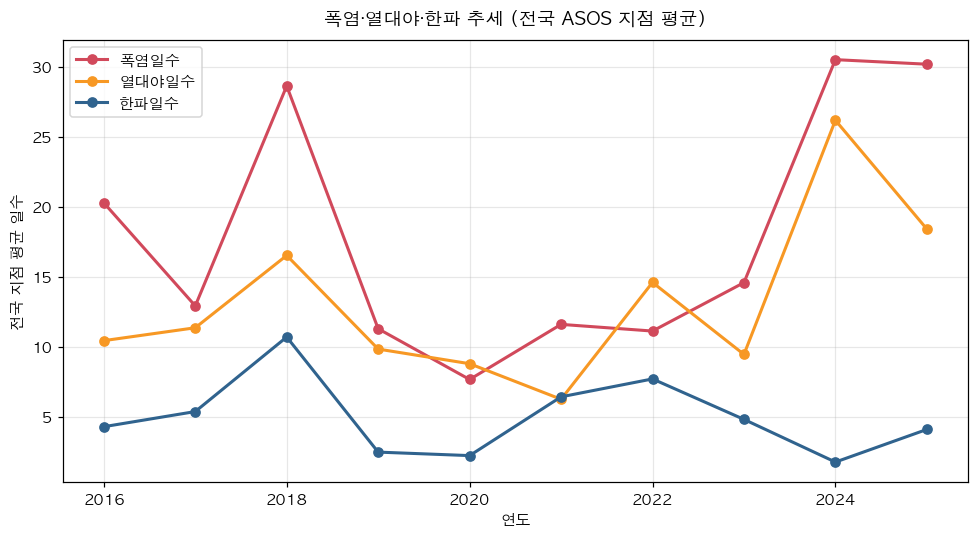

In [11]:
yearly = (
    df[df["연도"].between(2016, 2025)]
    .groupby(["연도", "지표"])["일수"].mean().unstack()
)
display(yearly.round(1))

fig, ax = plt.subplots(figsize=(9, 5))
for col, c in [("폭염일수", "#d1495b"), ("열대야일수", "#f79824"), ("한파일수", "#30638e")]:
    if col in yearly:
        ax.plot(yearly.index, yearly[col], "o-", label=col, color=c, lw=2)
ax.set_xlabel("연도")
ax.set_ylabel("전국 지점 평균 일수")
ax.set_title("폭염·열대야·한파 추세 (전국 ASOS 지점 평균)", fontsize=12, pad=10)
ax.legend()
ax.grid(alpha=.3)
plt.tight_layout()
plt.show()

## 7. 결론 — 그래서 주소다

이 분석이 보여준 것:

1. **같은 시·도 안에서도 폭염일수는 크게 갈린다.** 관측지점 3곳 이상인 10개 시·도의 내부 격차는 평균 **18.3일**, 경상북도는 **34.0일**(1.0일 ~ 35.0일)에 달한다. 시·도로 묶어도 지점 간 편차는 **24%밖에 줄지 않는다**(전국 8.6일 → 시도 내부 6.6일). 행정구역은 위험을 설명하는 단위가 아니다.
2. **폭염과 한파를 함께 겪는 지역이 존재한다.** 분석 대상 86개 지점 중 **23개(27%)**가 두 지표 모두 중앙값을 넘는다. 계절별로 분리된 대책은 이 지역을 두 번 놓친다.
3. **낮 더위와 밤 더위는 사실상 무관하다**(상관계수 **-0.01**). 낮 기준 폭염특보로는 야간 주거 위험을 잡을 수 없다.

세 결론이 가리키는 방향은 같다 — **더 촘촘한 공간 기준자가 필요하다.**

그런데 기상 격자를 아무리 잘게 쪼개도, 그 격자 안의 **누가 위험한지**는 알 수 없다.
`지하 101호`와 `3층 302호`는 같은 격자, 같은 좌표, 같은 특보를 받지만 위험은 전혀 다르다.
이 둘을 구분하는 유일한 공공 데이터가 **상세주소**다.

### 기존 데이터로는 왜 안 되는가

| 데이터 | 한계 |
|---|---|
| 건축물대장 | 서울연구원 분석 — 주거용 지하층의 정확한 식별·집계가 사실상 불가능 |
| KOSIS 거주층별 가구 (DT_1PE1508) | 2015년 단일 시점 |
| 인구주택총조사 반지하·옥탑 | 2024년 등록센서스에서 최초 공표, 연 1회·행정구역 단위 |
| 기상 격자예보 | 5km, '누가 사는지'를 모름 |

### 주소가 메우는 공백

- **상세주소DB**는 `지하 1층 101호`·`옥탑` 같은 **거주 층 정보를 구조화된 형태로 이미 보유**한다.
- **국가지점번호**는 도로명주소가 없는 논밭·산지를 가리킬 수 있다.
  질병관리청 집계상 2025년 온열질환의 **44.3%가 실외작업장(32.1%)과 논밭(12.2%)에서 발생**했다 —
  즉 **주소가 없는 곳**이다.
- **사물주소**는 쉼터·그늘막처럼 건물이 아닌 대응 자원에 부를 수 있는 이름을 준다.

> 기상청은 격자를 준다. 행안부는 주소를 준다.
> **둘을 잇는 순간, '우리 동네 폭염'이 '우리 집 폭염'이 된다.**

세부 정책 과제는 제안서 본문을 참조.